In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")


In [14]:
path = r"C:\Users\X395\kuliah semester 5\PRAK_MACHINE_LEARNING\TUGAS 10\students_dropout_academic_success.csv"
df = pd.read_csv(path)

df.head()


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [15]:
df.describe()


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [16]:
target = "target"   # sesuai yang kamu dapat tadi

df[target].value_counts()


target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

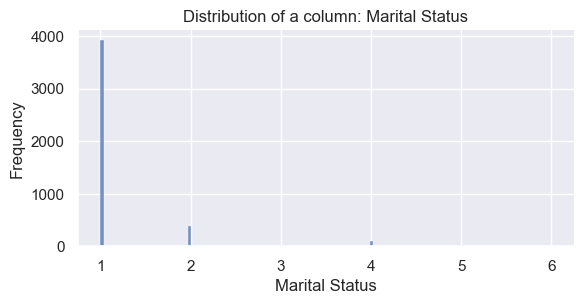

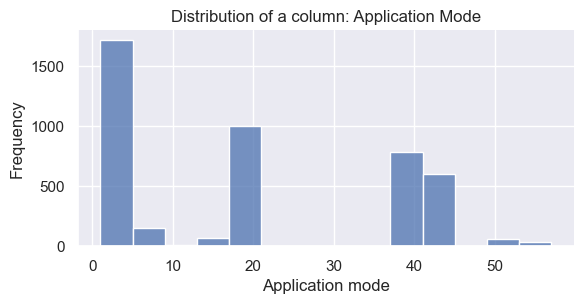

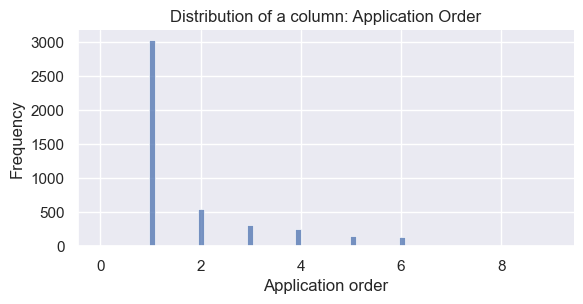

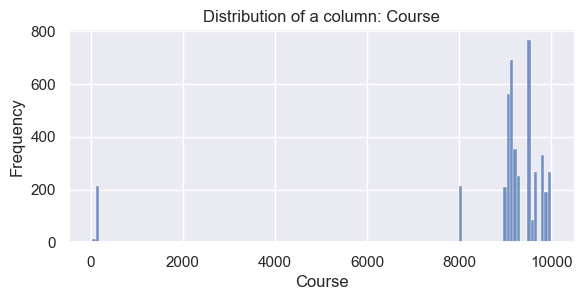

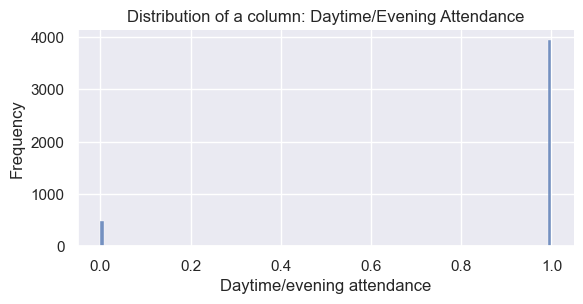

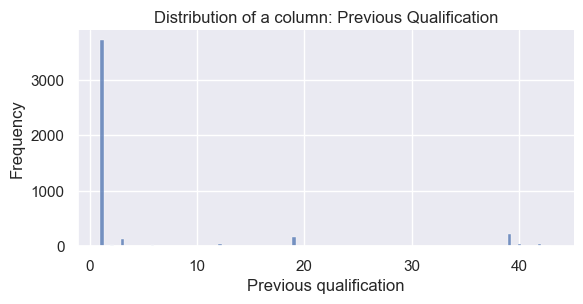

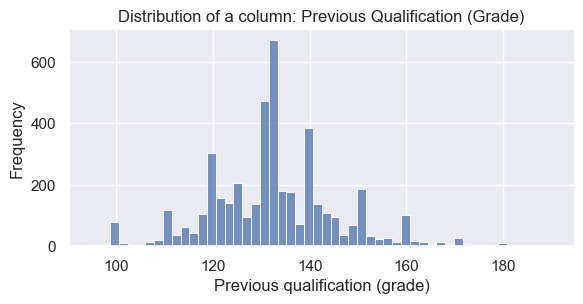

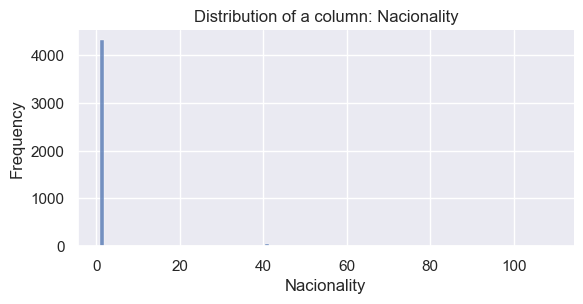

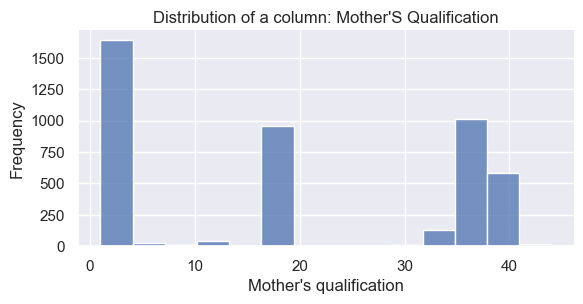

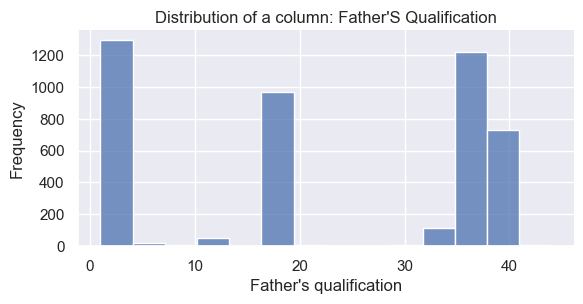

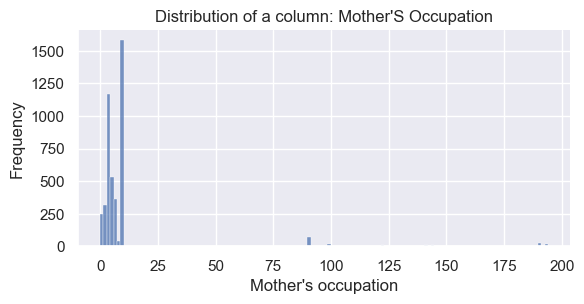

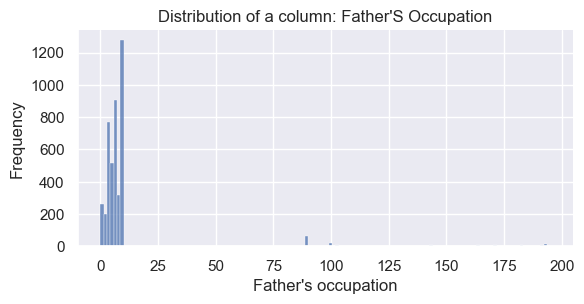

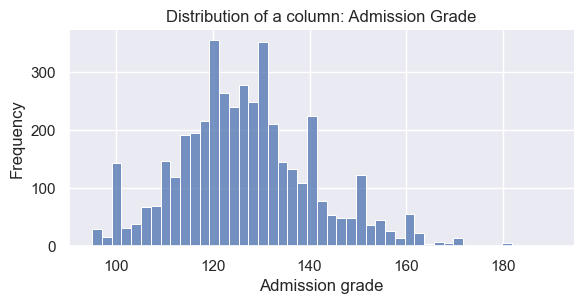

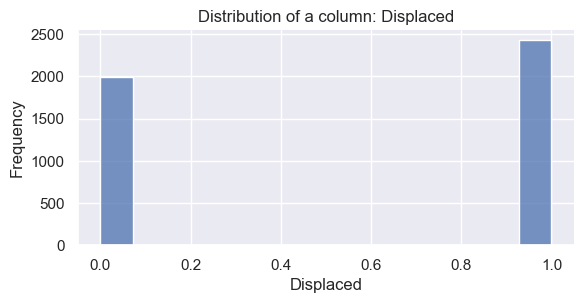

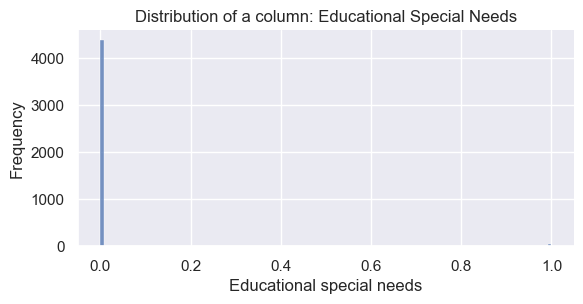

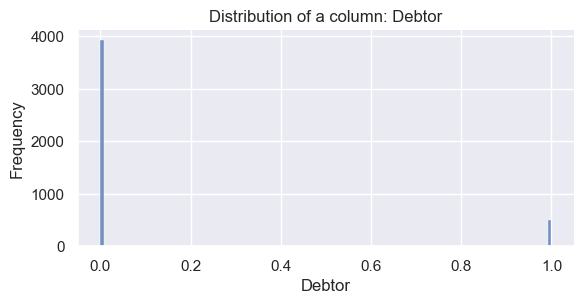

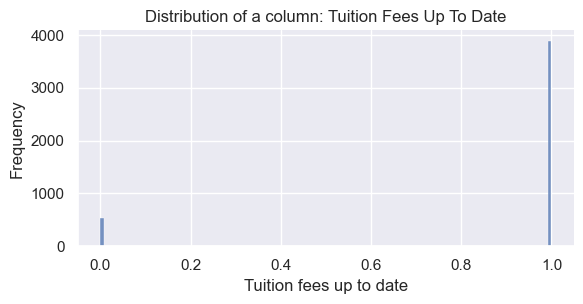

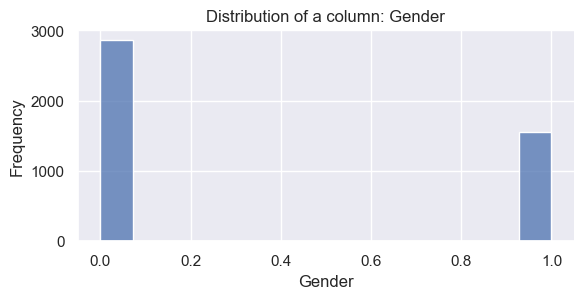

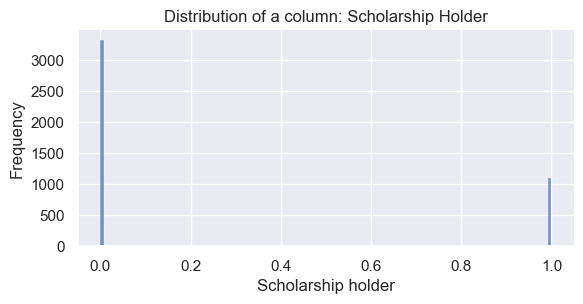

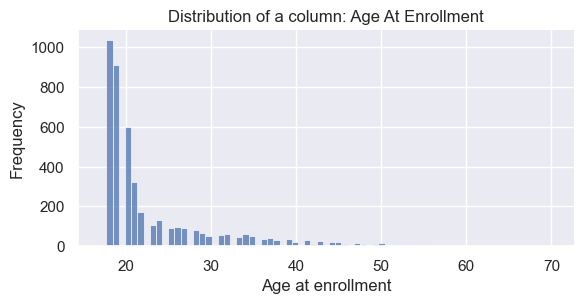

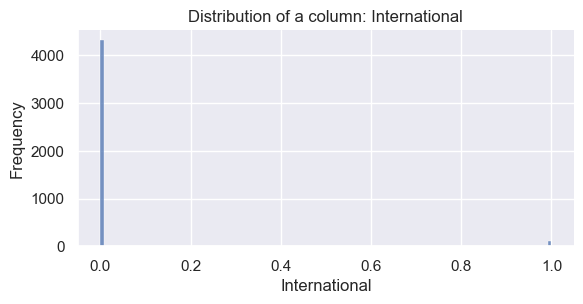

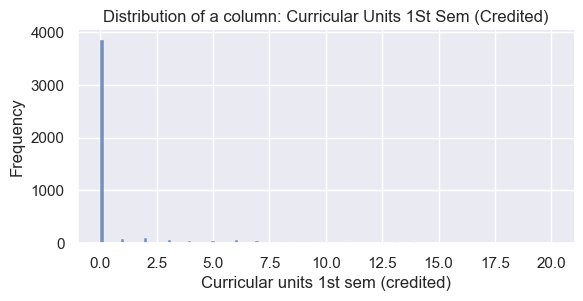

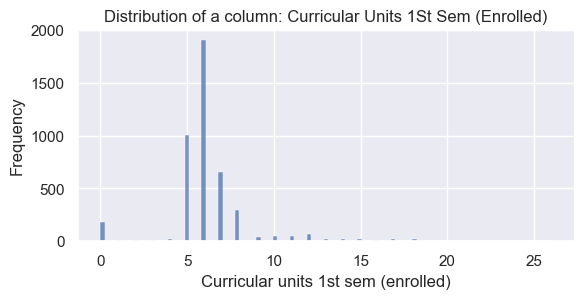

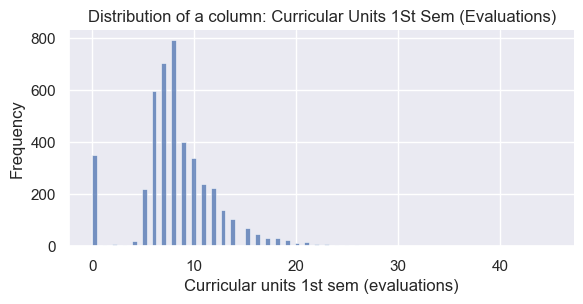

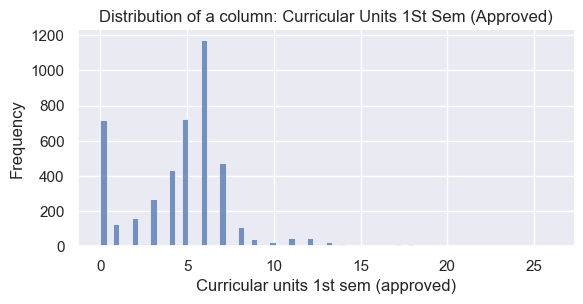

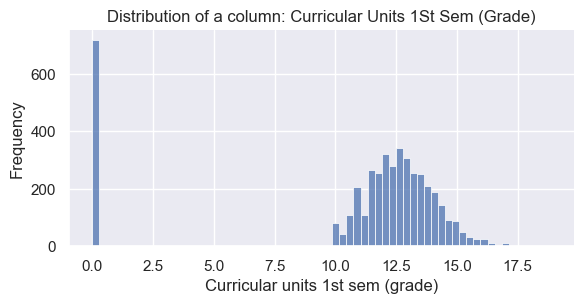

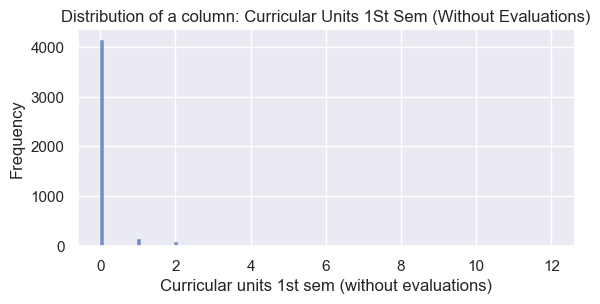

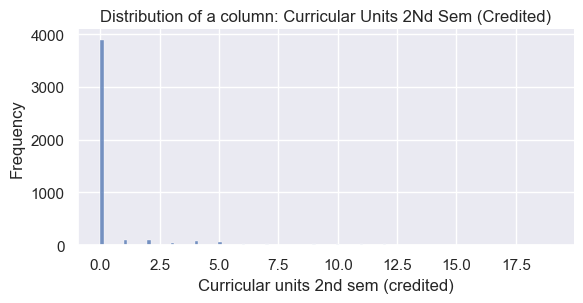

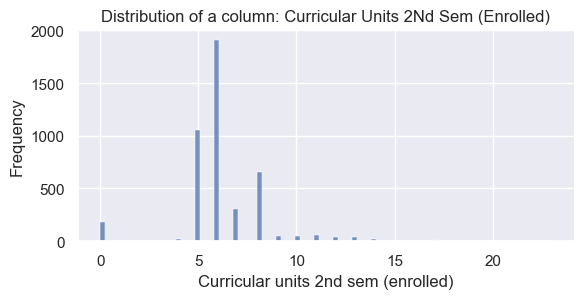

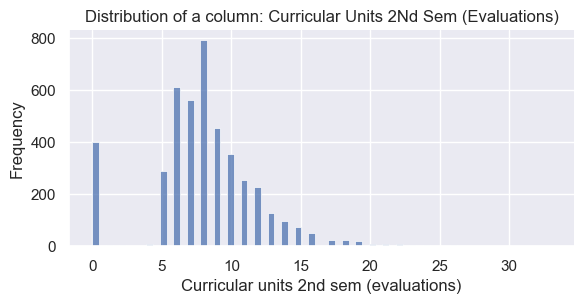

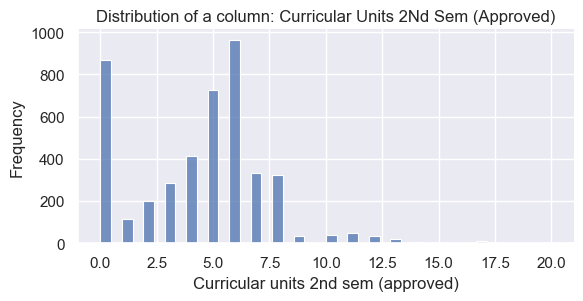

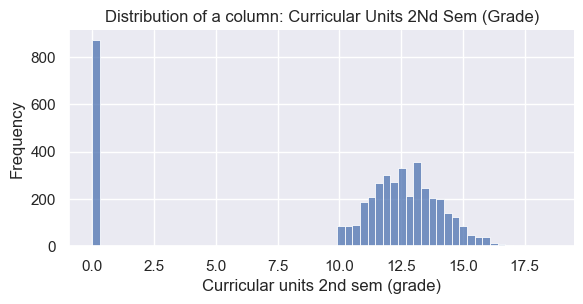

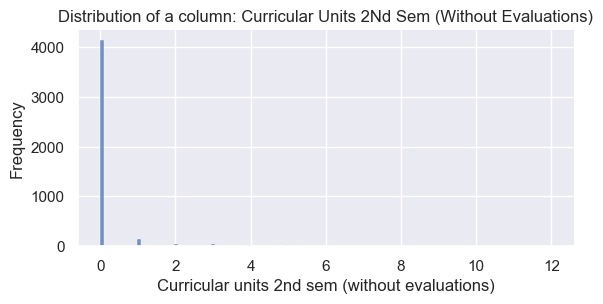

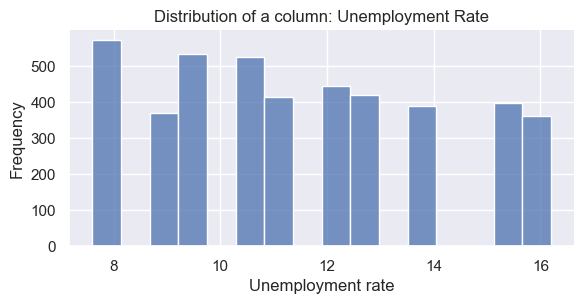

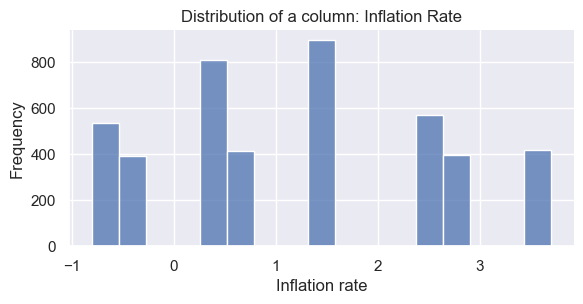

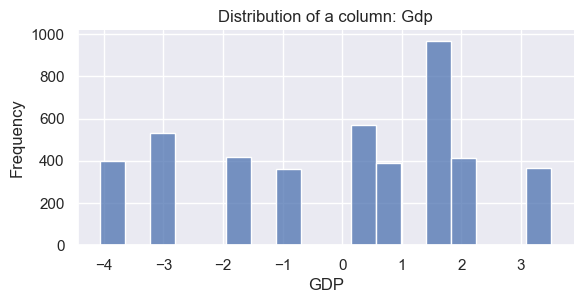

In [17]:
sns.set_theme()

numerical_cols = df.columns[df.dtypes != object]

for column in numerical_cols:
    sns.displot(df[column], height=3, aspect=2)
    plt.ylabel('Frequency')
    plt.title('Distribution of a column: {}'.format(column.title()))
    plt.show()


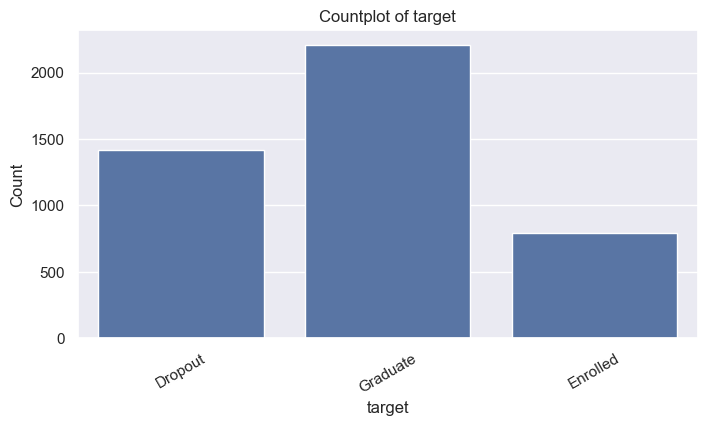

In [18]:
categorical_cols = df.columns[df.dtypes == object]

if len(categorical_cols) > 0:
    for column in categorical_cols:
        fig, ax = plt.subplots(figsize=(8,4))
        sns.countplot(data=df, x=column)
        plt.ylabel("Count")
        plt.xticks(rotation=30)
        plt.title(f"Countplot of {column}")
        plt.show()
else:
    print("Tidak ada kolom kategorikal bertipe object. Semua kolom numerik (kode kategori).")


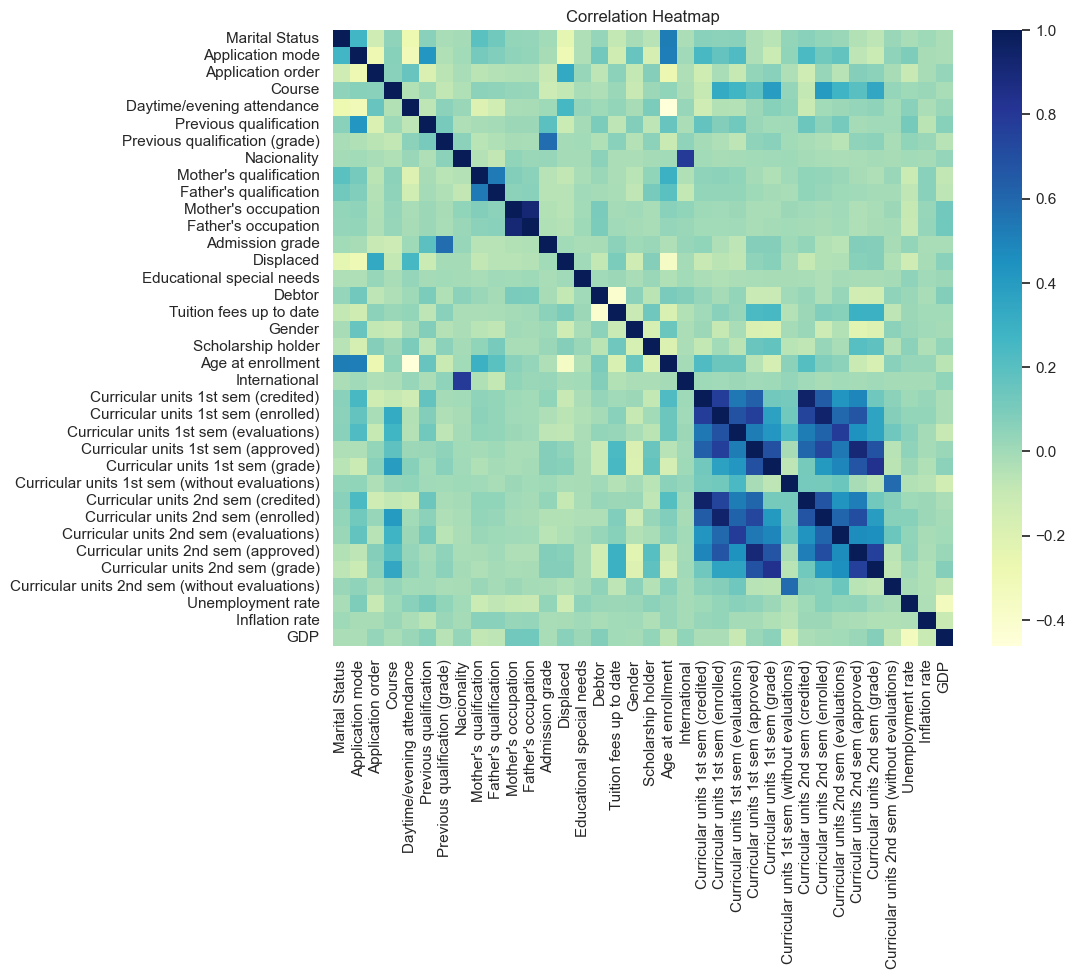

In [19]:
plt.figure(figsize=(10,8))

corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, cmap='YlGnBu', annot=False)

plt.title("Correlation Heatmap")
plt.show()


In [20]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# pisah fitur dan target
X = df.drop(columns=[target])
y = df[target]

# encode target
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y.values.ravel())

print("Mapping label:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, "=", cls)

# identifikasi numerik & kategorikal
numerical_cols = X.columns[X.dtypes != object]
categorical_cols = X.columns[X.dtypes == object]

# pipeline preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# transform fitur
X_processed = preprocessor.fit_transform(X)

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_train.shape, X_test.shape


Mapping label:
0 = Dropout
1 = Enrolled
2 = Graduate


((3539, 36), (885, 36))

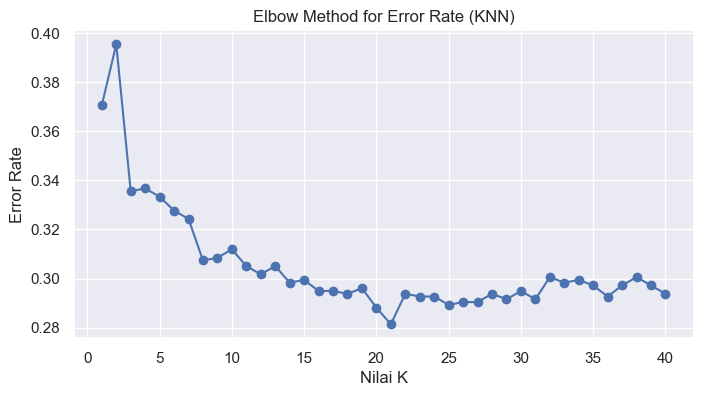

K terbaik: 21
Error minimum: 0.28135593220338984


In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

error_rates = []
k_range = range(1, 41)

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    y_pred_k = knn_k.predict(X_test)
    error = 1 - accuracy_score(y_test, y_pred_k)
    error_rates.append(error)

plt.figure(figsize=(8,4))
plt.plot(k_range, error_rates, marker='o')
plt.xlabel("Nilai K")
plt.ylabel("Error Rate")
plt.title("Elbow Method for Error Rate (KNN)")
plt.grid(True)
plt.show()

k_best = k_range[np.argmin(error_rates)]
print("K terbaik:", k_best)
print("Error minimum:", min(error_rates))


In [22]:
from sklearn.metrics import classification_report, f1_score

knn = KNeighborsClassifier(n_neighbors=k_best)  # otomatis pakai hasil elbow
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
print('Accuracy score: ', round(accuracy_score(y_test, y_pred), 4))
print('F1 Score (weighted): ', round(f1_score(y_test, y_pred, average='weighted'), 4))


              precision    recall  f1-score   support

     Dropout       0.84      0.63      0.72       284
    Enrolled       0.52      0.21      0.30       159
    Graduate       0.70      0.96      0.81       442

    accuracy                           0.72       885
   macro avg       0.69      0.60      0.61       885
weighted avg       0.71      0.72      0.69       885

Accuracy score:  0.7186
F1 Score (weighted):  0.6875


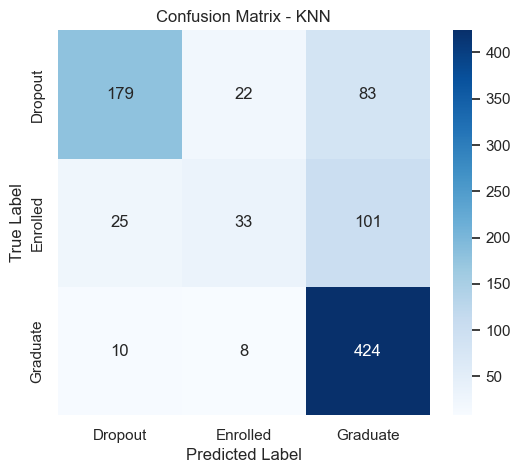

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [24]:
# ambil 1 baris sebagai template format input
dummy = X.iloc[[0]].copy()

# contoh ubah nilai (opsional)
# dummy["Admission grade"] = 120
# dummy["Age at enrollment"] = 21

dummy_processed = preprocessor.transform(dummy)
dummy_pred = knn.predict(dummy_processed)

print("Prediksi dummy mahasiswa baru:", label_encoder.inverse_transform(dummy_pred)[0])


Prediksi dummy mahasiswa baru: Graduate


In [25]:
# === Auto-save trained artifacts (model, preprocessor, label encoder) ===
import os, pickle
try:
    import joblib
    _use_joblib = True
except Exception:
    _use_joblib = False

os.makedirs('models', exist_ok=True)

# Intelligent detection of variables in notebook namespace
g = globals()

found = {}
# common names
name_candidates = {
    'model': ['model', 'knn', 'clf', 'classifier', 'best_model', 'final_model', 'knn_model'],
    'preprocessor': ['preprocessor', 'pipeline', 'scaler', 'transformer', 'preproc_pipeline'],
    'label_encoder': ['label_encoder', 'le', 'encoder']
}

for key, names in name_candidates.items():
    for n in names:
        if n in g:
            found[key] = (g[n], n)
            break

# type-based fallback
def find_by_type(type_tuple):
    for k, v in g.items():
        try:
            if isinstance(v, type_tuple):
                return v, k
        except Exception:
            continue
    return None, None

if 'model' not in found:
    try:
        from sklearn.neighbors import KNeighborsClassifier
        obj, nm = find_by_type((KNeighborsClassifier,))
        if obj is not None:
            found['model'] = (obj, nm)
    except Exception:
        pass

if 'preprocessor' not in found:
    try:
        from sklearn.compose import ColumnTransformer
        from sklearn.pipeline import Pipeline
        types = (ColumnTransformer, Pipeline)
        obj, nm = find_by_type(types)
        if obj is not None:
            found['preprocessor'] = (obj, nm)
    except Exception:
        pass

if 'label_encoder' not in found:
    try:
        from sklearn.preprocessing import LabelEncoder
        obj, nm = find_by_type((LabelEncoder,))
        if obj is not None:
            found['label_encoder'] = (obj, nm)
    except Exception:
        pass

saved = []
for key in ('model', 'preprocessor', 'label_encoder'):
    entry = found.get(key)
    if entry is None:
        print(f'-- {key} not found in notebook namespace (skipping).')
        continue
    obj, varname = entry
    path = os.path.join('models', f'{key}.pkl')
    try:
        if _use_joblib:
            joblib.dump(obj, path)
        else:
            with open(path, 'wb') as f:
                pickle.dump(obj, f)
        print(f'Saved `{varname}` as {path}')
        saved.append(path)
    except Exception as e:
        print(f'Failed to save {key} from variable `{varname}` -> {path}:', e)

if not saved:
    print('\nNo artifacts were saved. Make sure you run this cell after training and that variables exist.')
else:
    print('\nSaved files:')
    for p in saved:
        print('-', p)

if 'label_encoder' in found:
    try:
        le = found['label_encoder'][0]
        classes = getattr(le, 'classes_', None)
        if classes is not None:
            print('\nLabel mapping (index -> class):')
            for i, c in enumerate(classes):
                print(i, '->', c)
    except Exception:
        pass

# End auto-save cell

Saved `knn` as models\model.pkl
Saved `preprocessor` as models\preprocessor.pkl
Saved `label_encoder` as models\label_encoder.pkl

Saved files:
- models\model.pkl
- models\preprocessor.pkl
- models\label_encoder.pkl

Label mapping (index -> class):
0 -> Dropout
1 -> Enrolled
2 -> Graduate
